In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=True)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X, Y=mnist.data[:1000], mnist.target[:1000]

In [4]:
data= X.copy()
data['y']=Y
data.to_csv('mnist.csv')

In [5]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
Y

,class
0,5
1,0
2,4
3,1
4,9
...,...
995,7
996,6
997,0
998,3


In [7]:
Y.value_counts()

,count
class,
7,117
1,116
4,105
9,100
2,99
0,97
6,94
3,93
5,92


In [8]:
x=np.array(X)
y=np.array(Y)

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=1)

In [10]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((700, 784), (300, 784), (700,), (300,))

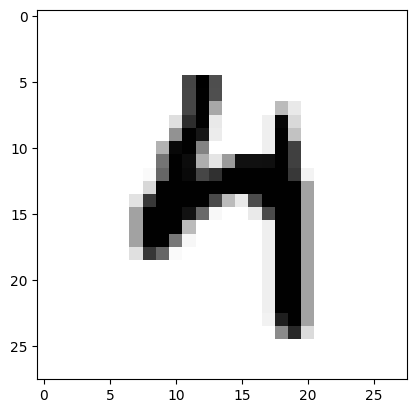

In [11]:
i=0
xi_image=x_train[i].reshape(28,28)
plt.imshow(xi_image, cmap='binary')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
x_train_prep=std.fit_transform(x_train)

In [18]:
from sklearn.model_selection import cross_val_score

In [20]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(loss='log_loss',random_state=1)
sgd_scores=cross_val_score(sgd_clf, x_train_prep, y_train, cv=10, scoring='accuracy')
sgd_scores

array([0.78571429, 0.8       , 0.78571429, 0.87142857, 0.8       ,
       0.88571429, 0.87142857, 0.9       , 0.95714286, 0.85714286])

In [21]:
sgd_scores.mean(), sgd_scores.std()

(np.float64(0.8514285714285714), np.float64(0.054285714285714284))

In [22]:
from sklearn.svm import SVC
svc_clf=SVC(random_state=1)
svc_scores=cross_val_score(svc_clf, x_train_prep, y_train, cv=10, scoring='accuracy')
svc_scores

array([0.8       , 0.8       , 0.81428571, 0.9       , 0.82857143,
       0.84285714, 0.88571429, 0.9       , 0.91428571, 0.87142857])

In [23]:
svc_scores.mean(), svc_scores.std()

(np.float64(0.8557142857142859), np.float64(0.04162514938380989))

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier(random_state=1)
rf_scores=cross_val_score(rf_clf, x_train_prep, y_train, cv=10, scoring='accuracy')
rf_scores

array([0.8       , 0.82857143, 0.87142857, 0.92857143, 0.85714286,
       0.88571429, 0.91428571, 0.92857143, 0.92857143, 0.85714286])

In [25]:
rf_scores.mean(), rf_scores.std()

(np.float64(0.8800000000000001), np.float64(0.04295227536677973))

In [26]:
from sklearn.model_selection import GridSearchCV

In [28]:
param_grid=[
    {'n_estimators':[100,300,500], 'max_features': [4,8,12]},
    {'bootstrap':[False], 'n_estimators':[300,500], 'max_features': [8,12]}
]

rf_clf=RandomForestClassifier(random_state=1)

grid_search=GridSearchCV(rf_clf, param_grid, cv=10, scoring='accuracy', return_train_score=True)
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'bootstrap': False, 'max_features': 12, 'n_estimators': 300}

In [29]:
rlt=grid_search.cv_results_
for mean_score, params in zip(rlt['mean_test_score'], rlt['params']):
    print(mean_score, params)

0.8885714285714286 {'max_features': 4, 'n_estimators': 100}
0.8800000000000001 {'max_features': 4, 'n_estimators': 300}
0.8828571428571429 {'max_features': 4, 'n_estimators': 500}
0.8828571428571429 {'max_features': 8, 'n_estimators': 100}
0.8885714285714286 {'max_features': 8, 'n_estimators': 300}
0.8885714285714286 {'max_features': 8, 'n_estimators': 500}
0.8785714285714287 {'max_features': 12, 'n_estimators': 100}
0.8885714285714286 {'max_features': 12, 'n_estimators': 300}
0.8885714285714286 {'max_features': 12, 'n_estimators': 500}
0.8928571428571429 {'bootstrap': False, 'max_features': 8, 'n_estimators': 300}
0.8971428571428571 {'bootstrap': False, 'max_features': 8, 'n_estimators': 500}
0.9014285714285715 {'bootstrap': False, 'max_features': 12, 'n_estimators': 300}
0.8928571428571429 {'bootstrap': False, 'max_features': 12, 'n_estimators': 500}


In [30]:
best_model=grid_search.best_estimator_

In [31]:
best_model.score(x_train, y_train)

1.0

In [32]:
from sklearn.metrics import confusion_matrix
y_test_pred=best_model.predict(x_train)
conf=confusion_matrix(y_train, y_test_pred)
conf

array([[68,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 81,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 69,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 65,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 74,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 64,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 66,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 82,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 61,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 70]])

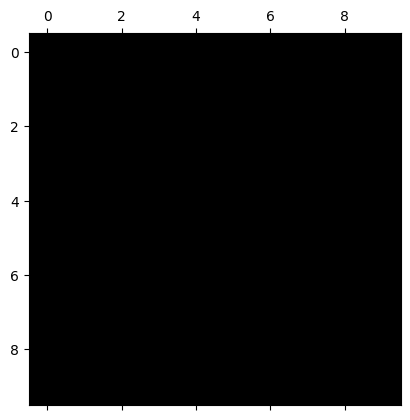

In [33]:
row_sums=conf.sum(axis=1, keepdims=True)
norm_conf=conf/row_sums
np.fill_diagonal(norm_conf, 0)
plt.matshow(norm_conf, cmap=plt.cm.gray)
plt.show()

In [34]:
imp=best_model.feature_importances_

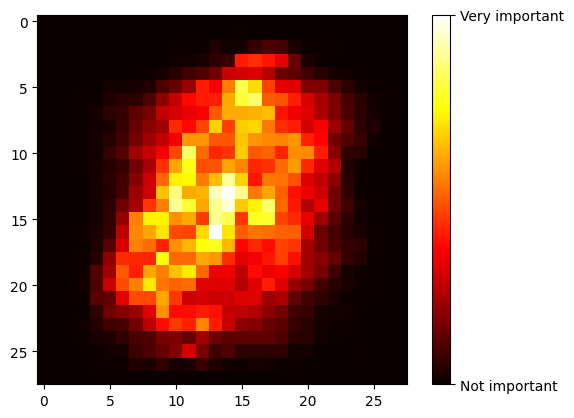

In [35]:
import matplotlib as mpl

plt.imshow(imp.reshape(28,28), cmap=mpl.cm.hot)
cbar=plt.colorbar(ticks=[imp.min(), imp.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'])
plt.show()

In [36]:
final_model=best_model

In [37]:
import joblib
joblib.dump(final_model, 'mnist_model.pkl')

['mnist_model.pkl']

In [38]:
model_clf_loaded=joblib.load('mnist_model.pkl')

In [39]:
model_clf_loaded.predict(x_test[:10])

array(['3', '4', '0', '6', '3', '7', '9', '6', '2', '3'], dtype=object)